In [18]:
import matplotlib.pyplot as plt
from pytorch3dunet.datasets.dsb import TIF_txt_Dataset
import numpy as np
from model_ranking import get_random_colors

In [33]:
transformer_config = {
    "raw": [
        #{"name": "CropToFixed", "size": [256,256]},
        {"name": "PercentileNormalizer"},
        #{"name": "FixedClipping", "max_value": 2},
        #{"name": "ToTensor", "expand_dims": True},
    ],
    "label": [
        #{"name": "CropToFixed", "size": [256,256]},
        {"name": "Relabel"},
        {"name": "BlobsToMask", "append_label": True},
        #{"name": "ToTensor", "expand_dims": True},
    ]
}

In [34]:
dataset = TIF_txt_Dataset(
    image_dir="/g/kreshuk/talks/data/BBBC039/images",
    mask_dir="/g/kreshuk/talks/data/BBBC039/instance_annotations/instance_labels",
    phase='train',
    transformer_config=transformer_config,
    filenames_path="/g/kreshuk/talks/data/BBBC039/train.txt",
    global_norm=True,
    percentiles=[5,98]
)

In [16]:
raw, label = dataset[0]
print(raw.shape, label.shape)
print(np.unique(label[0]))

(1, 520, 696) (1, 520, 696)
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108]


In [36]:
i = 6
raw, label = dataset[i]
print(label.shape)

(2, 1, 520, 696)


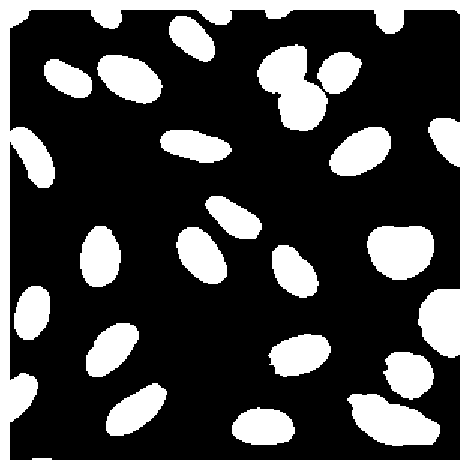

In [37]:
i = 6
raw, label = dataset[i]
# _ = plt.imshow(raw[0,100:400, 300:600].squeeze(), cmap='magma')
# _ = plt.axis("off")
# plt.tight_layout()
# plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/images/BBBC039_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
# plt.show()

# _ = plt.imshow(label[0,100:400, 300:600].squeeze(), cmap=get_random_colors(label[0,100:400, 300:600]), interpolation="nearest")
# _ = plt.axis("off")
# plt.tight_layout()
# plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/images/BBBC039_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
# plt.show()

_ = plt.imshow(label[0, 0, 100:400, 300:600].squeeze(), cmap='grey', interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/images/BBBC039_sem_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

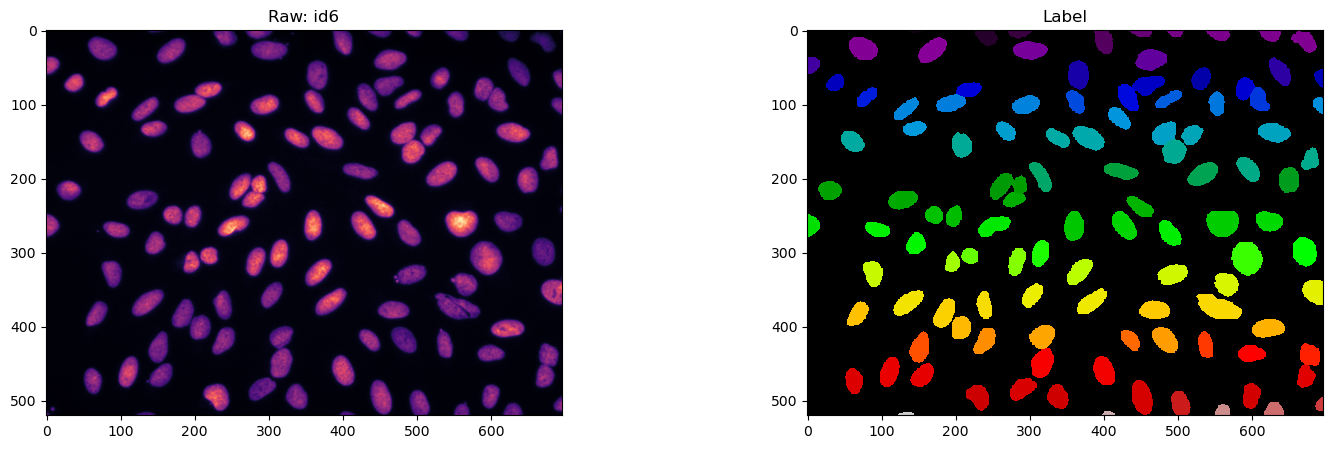

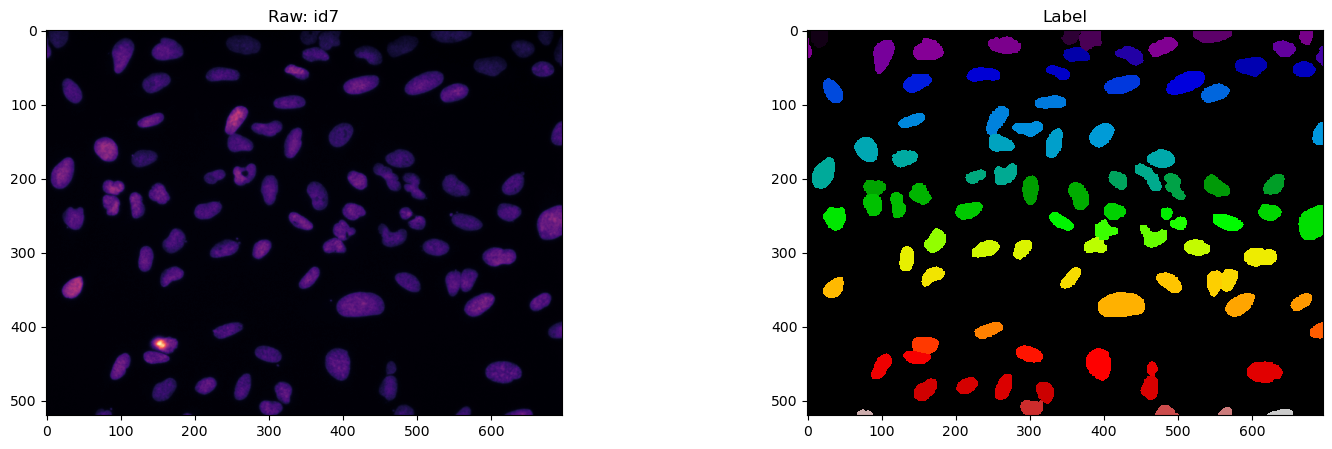

In [17]:
for i in range(6, 8):
    raw, label = dataset[i]
    _, axs = plt.subplots(1, 2, figsize=(18, 5))
    axs[0].imshow(raw[0].squeeze(), cmap="magma")
    axs[0].set_title(f"Raw: id{i}")
    axs[1].imshow(label[0].squeeze(), interpolation="nearest", cmap="nipy_spectral")
    axs[1].set_title("Label")
    plt.show()